In [1]:
pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 3.2 MB/s eta 0:00:22
   - -------------------------------------- 1.8/69.5 MB 3.3 MB/s eta 0:00:21
   - -------------------------------------- 2.1/69.5 MB 3.0 MB/s eta 0:00:23
   - -------------------------------------- 3.1/69.5 MB 3.2 MB/s eta 0:00:21
   -- ------------------------------------- 4.2/69.5 MB 3.5 MB/s eta 0:00:19
   -- ------------------------------------- 4.7/69.5 MB 3.5 MB/s eta 0:00:19
   --- ------------------------------------ 5.8/69.5 MB 3.7 MB/s eta 0:00:18
   --- ------------------------------------ 6.0/69.5 MB 3.5 MB/s eta 0:00:19
   --- ------------------------------------ 6.3/69.5 MB 3.4 MB/s eta 0:00:19
   --- ------------------------------------ 6.8/69.5 MB 3.1 MB/s eta 0:00:21
   ---- ------------

# XGBoost Regressor

## Problem Statement

In this notebook, we will implement the XGBoost Regressor algorithm using Python.

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds multiple decision trees sequentially to improve prediction accuracy.

## Dataset Used

We will use the **Diamonds Dataset** from Seaborn.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

## Dataset Loading

Now we will load the Diamonds dataset and convert it into a Pandas DataFrame.

In [3]:
df = sns.load_dataset("diamonds")

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Exploratory Data Analysis (EDA)

In this step, we will check:

- Dataset shape
- Missing values
- Data types
- Statistical summary
- Correlation analysis
- Data Visualization

In [4]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (53940, 10)

Missing Values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Data Types:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
df.select_dtypes(include=["int64", "float64"]).corr()

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


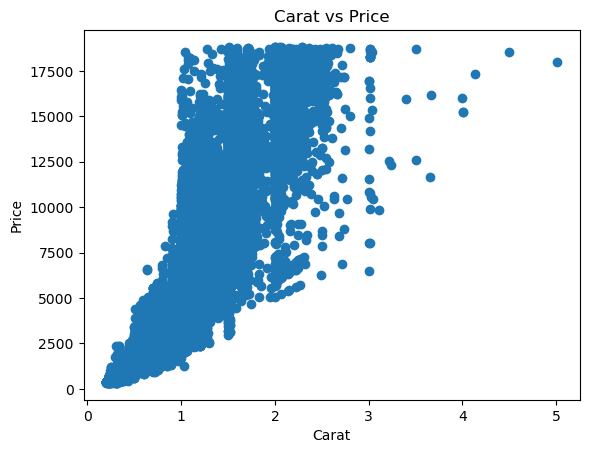

In [6]:
plt.scatter(df["carat"], df["price"])

plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Price")

plt.show()

## Data Preprocessing

In this dataset:

- There are no missing values.
- Some columns are categorical.
- We will encode categorical variables before training the model.

In [7]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,False,True,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,True,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,False,True,...,False,False,True,False,False,False,False,False,True,False


In [8]:
X = df.drop("price", axis=1)
y = df["price"]

X.head()

,carat,depth,table,x,y,z,cut_Premium,cut_Very Good,cut_Good,cut_Fair,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0.23,61.5,55.0,3.95,3.98,2.43,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0.21,59.8,61.0,3.89,3.84,2.31,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,False,False,True,False,...,False,False,True,False,False,False,False,False,True,False


## Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (43152, 23)
Testing Shape: (10788, 23)


## Model Building

Now we will create the XGBoost Regressor model.

Parameters used:

- n_estimators = 100
- learning_rate = 0.1
- max_depth = 5

In [10]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

## Model Training

Now we will train the XGBoost Regressor model using the training dataset.

In [11]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Model Prediction

Now we will predict the diamond prices using the testing dataset.

In [12]:
y_pred = xgb_model.predict(X_test)

y_pred[:10]

array([  664.1263,  2318.952 ,  1185.3687,  1305.3624, 10017.492 ,
        3736.8257,  1880.7925,  1769.5288,  2236.139 ,  5921.988 ],
      dtype=float32)

## Model Evaluation

We will evaluate the model using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 329.6241149902344
MSE : 419446.46875
RMSE : 647.6468704085584
R² Score : 0.9736144542694092


## Result Interpretation

XGBoost Regressor builds multiple trees sequentially.

Each new tree learns from the mistakes of the previous trees, resulting in higher prediction accuracy.

A lower RMSE and higher R² score indicate better model performance.

In [14]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
1388,559,664.126282
50052,2201,2318.951904
41645,1238,1185.368652
42377,1304,1305.362427
17244,6901,10017.492188
1608,3011,3736.825684
46398,1765,1880.792480
45493,1679,1769.528809
49385,2102,2236.138916
10460,4789,5921.987793


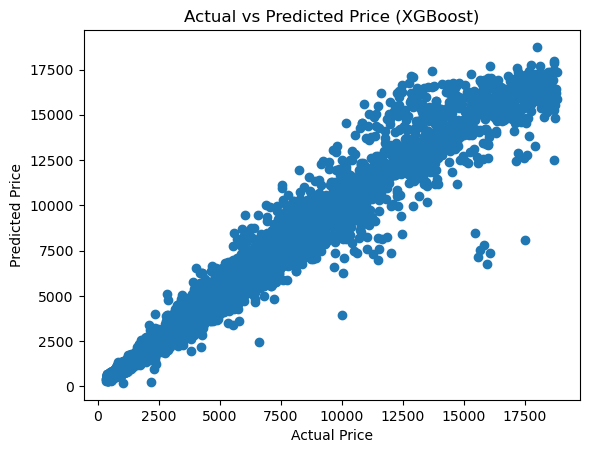

In [15]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (XGBoost)")

plt.show()

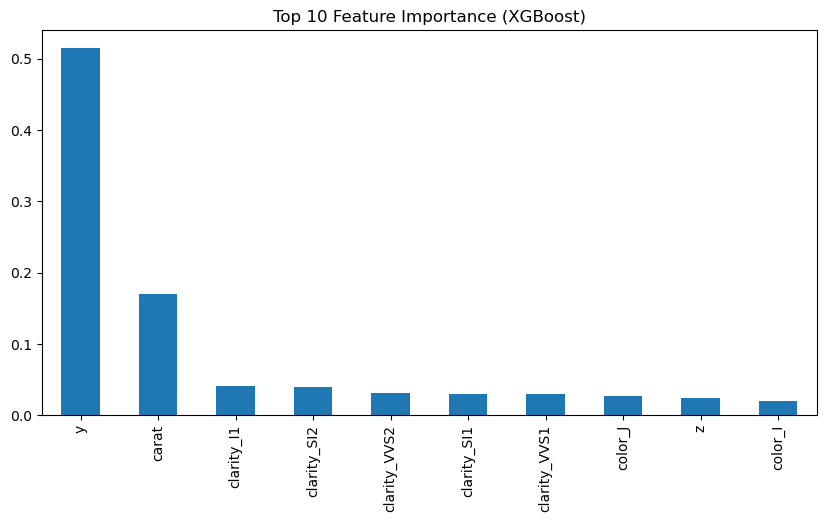

In [16]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

## Conclusion

In this notebook, we successfully implemented the XGBoost Regressor algorithm.

The following steps were completed:

- Dataset Loading
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Train-Test Split
- Model Building
- Model Training
- Model Prediction
- Model Evaluation
- Feature Importance Analysis

XGBoost Regressor is one of the most powerful machine learning algorithms for regression tasks and is widely used in real-world applications such as house price prediction, sales forecasting, medical prediction, and financial analysis.